# Deep Q-Learning for Atari Breakout
**Author:** [Jacob Chapman](https://twitter.com/jacoblchapman) and [Mathias Lechner](https://twitter.com/MLech20)<br>
**Date created:** 2020/05/23<br>
**Last modified:** 2020/06/17<br>
**Description:** Play Atari Breakout with a Deep Q-Network.  
https://keras.io/examples/rl/deep_q_network_breakout/

## Setup

In [ ]:
!python --version
# Python 3.10.12
# Python 3.11.13

Python 3.11.13


In [ ]:
%%time
# Atari ROM 라이선스를 포함하여 gym 설치
!pip install --upgrade gymnasium[atari]
!pip install --upgrade ale-py

CPU times: user 3.07 s, sys: 638 ms, total: 3.71 s
Wall time: 8.49 s


In [ ]:
import random
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time

import warnings
warnings.filterwarnings("ignore")

In [ ]:

import gymnasium as gym
import ale_py # 수정: Atari 환경을 gymnasium에 등록하기 위해 명시적으로 import

from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
import numpy as np
import random

# Print versions to confirm
print(f"Gymnasium version: {gym.__version__}")
print(f"Numpy version: {np.__version__}")

# Create and wrap the environment
env = gym.make("ALE/Breakout-v5",render_mode="rgb_array", frameskip=1)
env = AtariPreprocessing(env,frame_skip=4, grayscale_obs=True)
# 수정: 변경된 이름인 FrameStackObservation 사용
env = FrameStackObservation(env, 4)

print('State space shape: ', env.observation_space.shape)
print('Action space: ', env.action_space.n)

Gymnasium version: 1.2.0
Numpy version: 2.0.2
State space shape:  (4, 84, 84)
Action space:  4


In [ ]:
# Epsilon-Greedy 정책 관련
epsilon_start = 1.0
epsilon_end = 0.1
epsilon_decay_steps = 1000000
epsilon_decay = (epsilon_start - epsilon_end) / epsilon_decay_steps

In [ ]:
"""## Q-Network 정의 """

class QNetwork(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(QNetwork, self).__init__()
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)

        def conv2d_size_out(size, kernel_size, stride):
            return (size - (kernel_size - 1) - 1) // stride  + 1

        convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(input_shape[1], 8, 4), 4, 2), 3, 1)
        convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(input_shape[2], 8, 4), 4, 2), 3, 1)
        linear_input_size = convw * convh * 64

        self.fc1 = nn.Linear(linear_input_size, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def forward(self, x):
        x = x / 255.0
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

"""## DQNAgent 클래스 정의"""

class DQNAgent:
    def __init__(self, env):
        self.env = env
        self.state_shape = env.observation_space.shape
        self.num_actions = env.action_space.n
        self.epsilon = epsilon_start
        self.memory = deque(maxlen=memory_size)
        self.q_network = QNetwork(self.state_shape, self.num_actions)
        self.target_q_network = QNetwork(self.state_shape, self.num_actions)
        self.update_target_model()
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.criterion = nn.SmoothL1Loss()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def get_action(self, state):
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(np.array(state)).unsqueeze(0)
                q_values = self.q_network(state_tensor)
                return torch.argmax(q_values).item()

    def replay(self):
        if len(self.memory) < batch_size:
            return 0

        minibatch = random.sample(self.memory, batch_size)
        states = torch.FloatTensor(np.array([t[0] for t in minibatch]))
        actions = torch.LongTensor([t[1] for t in minibatch]).unsqueeze(1)
        rewards = torch.FloatTensor([t[2] for t in minibatch]).unsqueeze(1)
        next_states = torch.FloatTensor(np.array([t[3] for t in minibatch]))
        dones = torch.FloatTensor([t[4] for t in minibatch]).unsqueeze(1)

        current_q_values = self.q_network(states).gather(1, actions)

        with torch.no_grad():
            max_next_q_values = self.target_q_network(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (1 - dones) * gamma * max_next_q_values

        loss = self.criterion(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        for param in self.q_network.parameters():
            param.grad.data.clamp_(-1.0, 1.0)
        self.optimizer.step()

        return loss.item()

    def update_target_model(self):
        self.target_q_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        if self.epsilon > epsilon_end:
            self.epsilon -= epsilon_decay

    def save_model(self, path):
        torch.save(self.q_network.state_dict(), path)
#        print(f"모델이 {path}에 저장되었습니다.")

    def load_model(self, path):
        self.q_network.load_state_dict(torch.load(path))
        self.q_network.eval()
        print(f"모델을 {path}에서 불러왔습니다.")


## Train

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
%%time

# 학습 관련
learning_rate = 0.001 #0.00025
gamma = 0.99
batch_size = 32
memory_size = 10000

# 네트워크 및 학습 시작 설정
target_update_freq = 50   #10000 # steps
update_after_actions = 4  # 4번의 행동마다 한번 학습
start_steps = batch_size*2
model_path = path+"models/DRL/DQN.pth"
total_steps = 0
max_mean_score = 1.0
max_episodes = 1000
max_steps_per_episode = 500

scores = []
losses = []

agent = DQNAgent(env)
for e in range(1, max_episodes+1):
    state, info = env.reset()
    done = False
    episode_reward = 0

    for steps in range(1, max_steps_per_episode):  # 500

        total_steps += 1

        if total_steps < start_steps:
            action = env.action_space.sample()
        else:
            action = agent.get_action(state)
            agent.decay_epsilon()

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.remember(state, action, reward, next_state, done)
        state = next_state
        episode_reward += reward

        if total_steps > start_steps and total_steps % update_after_actions == 0:
            loss = agent.replay()
            losses.append(loss)
            if total_steps % target_update_freq == 0:
                agent.update_target_model()

        if done : break
    scores.append(episode_reward)
    mean_score = np.mean(scores[-100:])

    print(f"Episode {e}, Total Steps: {total_steps}, Score: {episode_reward}, Avg Score: {mean_score:.2f}, Epsilon: {agent.epsilon:.4f}")

    if mean_score > max_mean_score:
        max_mean_score = mean_score
        agent.save_model(model_path)
        print(f"New best model saved with avg score: {max_mean_score:.2f}")

#env.close()
print("학습 종료!")

#Wall time: 22min 59s

Episode 1, Total Steps: 186, Score: 1.0, Avg Score: 1.00, Epsilon: 0.9999
Episode 2, Total Steps: 314, Score: 0.0, Avg Score: 0.50, Epsilon: 0.9998
Episode 3, Total Steps: 504, Score: 1.0, Avg Score: 0.67, Epsilon: 0.9996
Episode 4, Total Steps: 700, Score: 1.0, Avg Score: 0.75, Epsilon: 0.9994
Episode 5, Total Steps: 959, Score: 3.0, Avg Score: 1.20, Epsilon: 0.9992
New best model saved with avg score: 1.20
Episode 6, Total Steps: 1262, Score: 4.0, Avg Score: 1.67, Epsilon: 0.9989
New best model saved with avg score: 1.67
Episode 7, Total Steps: 1395, Score: 0.0, Avg Score: 1.43, Epsilon: 0.9988
Episode 8, Total Steps: 1531, Score: 0.0, Avg Score: 1.25, Epsilon: 0.9987
Episode 9, Total Steps: 1721, Score: 1.0, Avg Score: 1.22, Epsilon: 0.9985
Episode 10, Total Steps: 1936, Score: 2.0, Avg Score: 1.30, Epsilon: 0.9983
Episode 11, Total Steps: 2162, Score: 2.0, Avg Score: 1.36, Epsilon: 0.9981
Episode 12, Total Steps: 2396, Score: 2.0, Avg Score: 1.42, Epsilon: 0.9979
Episode 13, Total 

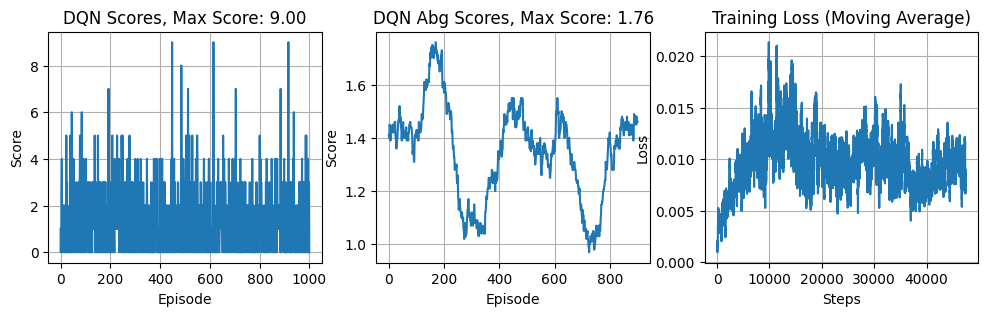

In [ ]:
"""## 학습 결과 시각화"""

def plot_moving_avg(data, window_size):
    if not data: return
    moving_avg = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg)

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.plot(scores)
plt.title(f'DQN Scores, Max Score: {max(scores):.2f}')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.grid()

plt.subplot(1, 3, 2)
plot_moving_avg(scores, 100)
plt.title(f'DQN Abg Scores, Max Score: {max_mean_score:.2f}')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.grid()

plt.subplot(1, 3, 3)
plot_moving_avg(losses, 100)
plt.title('Training Loss (Moving Average)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid()
plt.show()


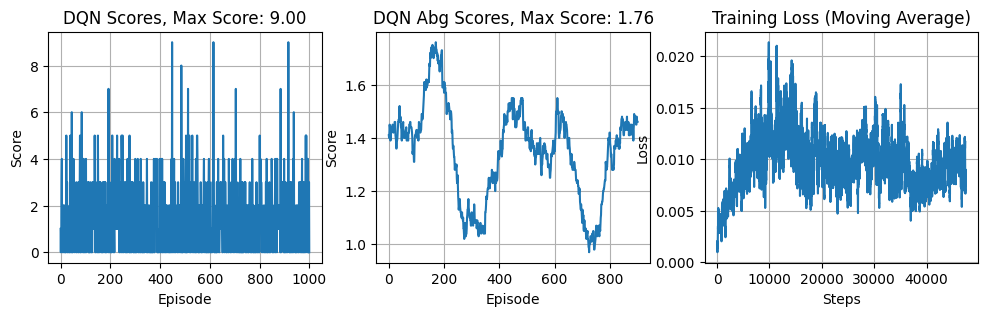

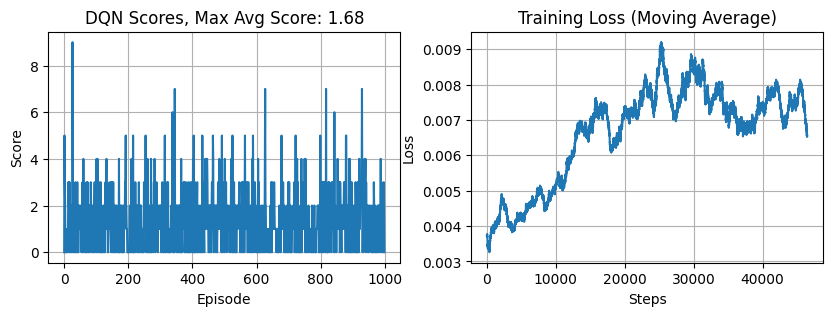

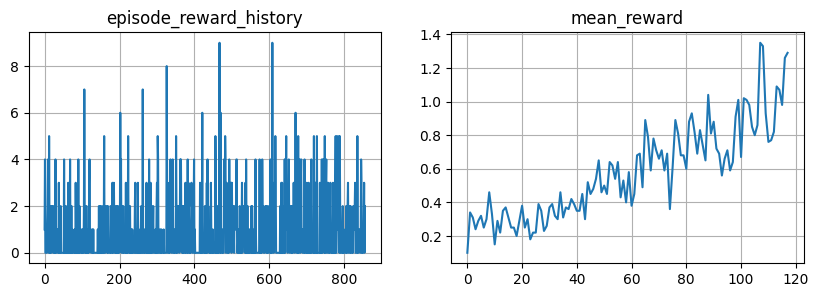

# Evaluation

In [ ]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from pyvirtualdisplay import Display
virtual_display = Display(visible=0, size=(400, 300))
virtual_display.start()

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')

from variable_print import p,ps,pst
from render import  show_video, wrap_env, render_as_image

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Create and wrap the environment
env = gym.make("ALE/Breakout-v5",render_mode="rgb_array", frameskip=1)
env = AtariPreprocessing(env,frame_skip=4, grayscale_obs=True)
# 수정: 변경된 이름인 FrameStackObservation 사용
env = FrameStackObservation(env, 4)

# Virtual Env 생성
video_path = "./video"
eval_env = wrap_env(env, path=video_path, name_prefix="dqn-breakout")
state, info = eval_env.reset()

# 학습된 가중치를 불러올 새로운 에이전트 생성
agent_test = DQNAgent(eval_env)
agent_test.load_model(model_path)
agent_test.epsilon = 0.01 # 약간의 탐험 허용

모델을 /content/gdrive/MyDrive/Colab Notebooks/models/DRL/DQN.pth에서 불러왔습니다.


시연 종료! 최종 점수: 0.0


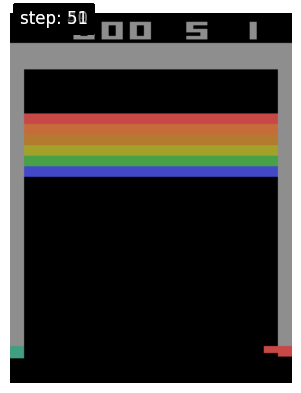

In [ ]:
"""## 학습된 에이전트 시연 (사용자 지정 방식)"""

step_cnt = 0
total_reward = 0

while True:
    render_as_image(eval_env, step=step_cnt)
    action = agent_test.get_action(state)
    next_state, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated
    state = next_state
    total_reward += reward

    if done or step_cnt>50 :
        print(f"시연 종료! 최종 점수: {total_reward}")
        break
    step_cnt += 1

#eval_env.close()

In [ ]:
# 저장된 비디오 표시
show_video(path=video_path, name_prefix="dqn-breakout")

./videovideo/dqn-breakout-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='DQN-episode-512')

/content/gdrive/MyDrive/Colab Notebooks/video/DQN-episode-512.mp4


## Visualizations
Before any training:
![Imgur](https://i.imgur.com/rRxXF4H.gif)

In early stages of training:
![Imgur](https://i.imgur.com/X8ghdpL.gif)

In later stages of training:
![Imgur](https://i.imgur.com/Z1K6qBQ.gif)

In [ ]:
show_video(path=path,name_prefix='DQN-episode-512')

/content/gdrive/MyDrive/Colab Notebooks/video/DQN-episode-512.mp4
